In [18]:
import pandas as pd

file = "/Users/sunny/Desktop/Amazon Statista/net_sales.xlsx"
df_revenue = pd.read_excel(file)

# year
df_revenue['year'] = df_revenue['Net sales revenue'].str[-2:]
df_revenue['year'] = '20' + df_revenue['year']

yearly_sales = df_revenue.groupby('year')['revenue(billion)'].sum().reset_index()

print(yearly_sales)
df_revenue

    year  revenue(billion)
0   2007             14.84
1   2008             19.16
2   2009             24.51
3   2010             34.21
4   2011             48.08
5   2012             61.10
6   2013             74.45
7   2014             88.99
8   2015            107.02
9   2016            135.98
10  2017            177.91
11  2018            232.89
12  2019            280.52
13  2020            386.07
14  2021            469.82
15  2022            513.97
16  2023            574.78
17  2024            637.96
18  2025            716.93


,Net sales revenue,revenue(billion),year
0,Q1 '07,3.02,2007
1,Q2 '07,2.89,2007
2,Q3 '07,3.26,2007
3,Q4 '07,5.67,2007
4,Q1 '08,4.14,2008
...,...,...,...
71,Q4 '24,187.79,2024
72,Q1 '25,155.67,2025
73,Q2 '25,167.70,2025
74,Q3 '25,180.17,2025


In [32]:
import pandas as pd

file = "/Users/Desktop/Amazon Statista/prime.xlsx"
df_sales = pd.read_excel('/Users/sunny/Desktop/Amazon Statista/prime.xlsx')
print(df_sales.head())
df_sales

   Year  Sales(billion)
0  2016            0.99
1  2017            1.59
2  2018            2.62
3  2019            4.32
4  2020            6.17


,Year,Sales(billion)
0,2016,0.99
1,2017,1.59
2,2018,2.62
3,2019,4.32
4,2020,6.17
5,2021,7.31
6,2022,11.90
7,2023,12.70
8,2024,14.20
9,2025,23.80


In [33]:
print(df_sales.dtypes)
print(yearly_sales.dtypes)

Year                int64
Sales(billion)    float64
dtype: object
year                  int64
revenue(billion)    float64
dtype: object


In [34]:
yearly_sales["year"] = yearly_sales["year"].astype(int)

df_merge = pd.merge(df_sales, yearly_sales, left_on="Year", right_on="year")

df_merge["prime_share"] = df_merge["Sales(billion)"] / df_merge["revenue(billion)"]
df_merge["prime_share_pct"] = df_merge["prime_share"] * 100

print(df_merge[["Year", "Sales(billion)", "revenue(billion)", "prime_share_pct"]])

   Year  Sales(billion)  revenue(billion)  prime_share_pct
0  2016            0.99            135.98         0.728048
1  2017            1.59            177.91         0.893710
2  2018            2.62            232.89         1.124995
3  2019            4.32            280.52         1.539997
4  2020            6.17            386.07         1.598156
5  2021            7.31            469.82         1.555915
6  2022           11.90            513.97         2.315310
7  2023           12.70            574.78         2.209541
8  2024           14.20            637.96         2.225845
9  2025           23.80            716.93         3.319710


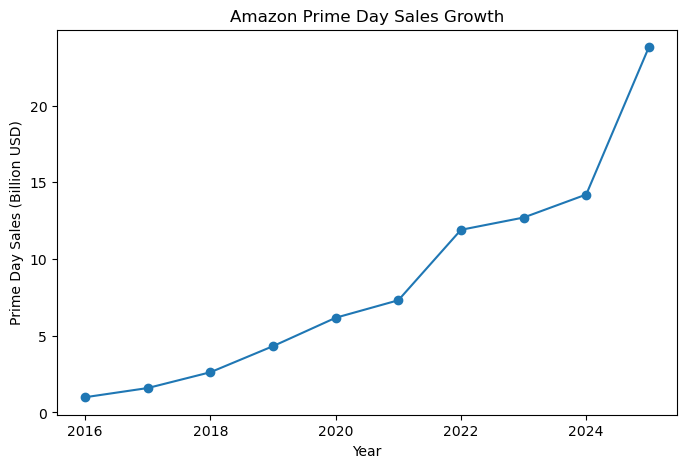

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_merge["Year"], df_merge["Sales(billion)"], marker="o")

plt.title("Amazon Prime Day Sales Growth")
plt.xlabel("Year")
plt.ylabel("Prime Day Sales (Billion USD)")

plt.show()

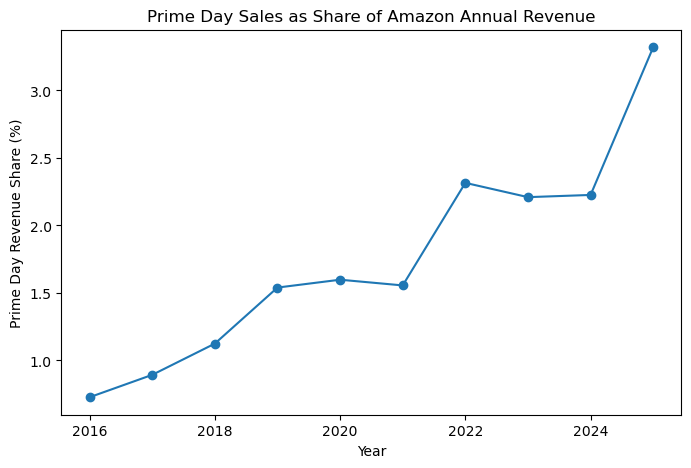

In [36]:
plt.figure(figsize=(8,5))
plt.plot(df_merge["Year"], df_merge["prime_share_pct"], marker="o")

plt.title("Prime Day Sales as Share of Amazon Annual Revenue")
plt.xlabel("Year")
plt.ylabel("Prime Day Revenue Share (%)")

plt.show()

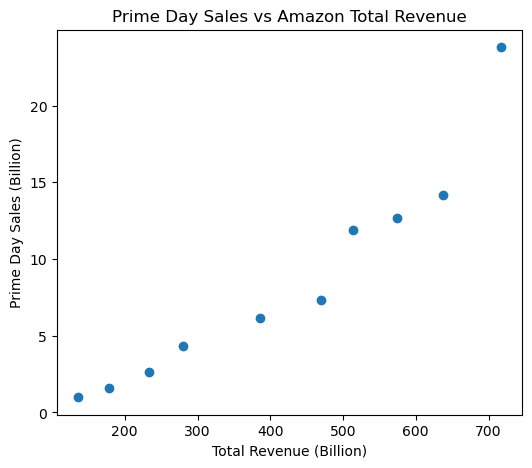

In [37]:
plt.figure(figsize=(6,5))

plt.scatter(df_merge["revenue(billion)"], df_merge["Sales(billion)"])

plt.xlabel("Total Revenue (Billion)")
plt.ylabel("Prime Day Sales (Billion)")
plt.title("Prime Day Sales vs Amazon Total Revenue")

plt.show()

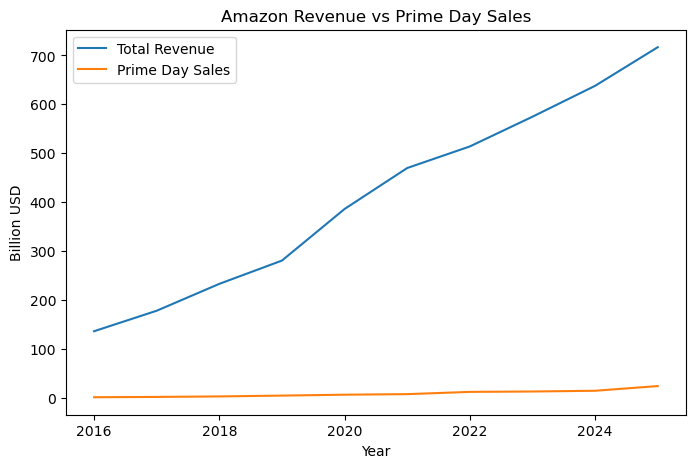

In [38]:
plt.figure(figsize=(8,5))

plt.plot(df_merge["Year"], df_merge["revenue(billion)"], label="Total Revenue")
plt.plot(df_merge["Year"], df_merge["Sales(billion)"], label="Prime Day Sales")

plt.legend()

plt.title("Amazon Revenue vs Prime Day Sales")
plt.xlabel("Year")
plt.ylabel("Billion USD")

plt.show()